# Point inside a polygon problem

This notebook summarizes how to obtain a more naive way to solve the following problem:

> If I have an n-side polygon represented by its vertices, and a point with coordinates (x, y). What is the best way to know if the point is inside the polygon?

This is because solving this question uses more than 90% of the execution tome inside the seismicity revision routine in the RSNC.

We will focus in how to solve this problem specifically for the RSNC, where the polygons are defined in several txt files inside the _bna_volcanic_files_ and _model_files_.

## Read files and obtain polygons vertices

Let's start by reading the polygon files available for the routine:

In [1]:
with open("../model_files/Modelo_Cesar.txt", 'r') as f:
    print(f.read())

"cesar", "cesar", 10
-73.72763313,9.292168602
-73.73477151,9.370690815
-73.74904828,9.445643837
-73.76332504,9.495612518
-73.78830938,9.563427157
-73.79166796,9.624946759
-73.79166717,9.735082534
-73.79166646,9.833280103
-73.83333312,9.833280102
-73.87499978,9.874946768
-73.87499978,9.916613435
-73.87500039,9.999959808
-73.83333258,9.999967632
-73.76320832,9.999979548
-73.70134234,9.99999006
-73.6299577,10.00000219
-73.54166741,10.00001719
-73.54166718,9.9397161
-73.54166693,9.874946824
-73.45833329,9.916613634
-73.41666629,9.95828011
-73.3746735,10.00003752
-73.25875825,9.999986956
-73.1666843,9.999946789
-73.16668008,9.901644911
-73.16667824,9.858814613
-73.16667498,9.782671452
-73.17629862,9.686786258
-73.16369209,9.574357062
-73.20814629,9.559036451
-73.25783218,9.532256101
-73.33145287,9.463489794
-73.42425185,9.388536773
-73.49206649,9.306445368
-73.53132759,9.245769112
-73.541315,9.181939
-73.597323,9.184529
-73.716443,9.191456
-73.72763313,9.292168602



As you can see, every file contains a first row with the name of the model and its subsequent lines relates every vertex inside the polygon. Now we can read every table inside model_files and save them in a specific variable. The files within model_files folder are:

In [2]:
import os

path = "../model_files"

# iterate through all file
for file in os.listdir(path):
    # Check whether file is in text format or not
    if file.endswith(".txt"):
        file_path = rf"{path}\{file}"
        print(file_path)

model_files\zona3.txt
model_files\Modelo_Cesar.txt
model_files\zona2.txt
model_files\zona_PtoGaitan.txt
model_files\zona5.txt
model_files\zona_vmm.txt
model_files\zona4.txt
model_files\zona1.txt
model_files\Modelo_CARMA.txt


Now, let's define a functions that takes a .txt file and converts it to a pandas dataframe:

In [3]:
import pandas as pd

def pandas_converter(filepath):
    df = pd.read_csv(filepath, names=['x', 'y'], skiprows=1)
    return df

# Example:
example_table = pandas_converter("../model_files/Modelo_CARMA.txt")
print(example_table.head())

         x     y
0 -76.0000   8.5
1 -76.0000  13.0
2 -71.0000  13.0
3 -71.0000   8.5
4 -73.3602   8.5


Now, to check if any point is outside the polygon we will use shapely, a Python library that has implemented a solution for this specific problem. Let me show you how you can do it with a simple example:

In [4]:
# Example taken from: https://blog.finxter.com/5-best-ways-to-check-if-a-point-is-inside-a-polygon-in-python/

from shapely.geometry import Point, Polygon

polygon = Polygon([(0, 0), (5, 0), (5, 5), (0, 5)])
point = Point(3,3)
print(polygon.contains(point))

True


So, let's convert the pandas dataframe into a shapely polygon and check if a point is inside it:

True


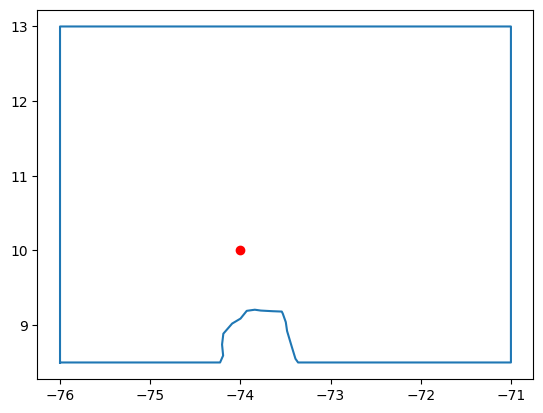

In [5]:
import matplotlib.pyplot as plt

# Create a polygon using the pandas table
polygon = Polygon(example_table.values)

# Create a point
point = Point(-74, 10)

# Check if the point is within the polygon
print(polygon.contains(point))

# Plot the polygon and the point
x, y = polygon.exterior.xy
plt.plot(x, y)
plt.scatter(point.x, point.y, color="red")
plt.show()

And as you can see, using this way we can see if the point is inside the polygon, wherever n-points it has. Let's try to time it using jupyter:

In [6]:
%%time
polygon.contains(point)

CPU times: user 1.6 ms, sys: 267 μs, total: 1.87 ms
Wall time: 1.31 ms


True

Let's compare with the previous version of the checking algorithm:

In [7]:
def inside_the_polygon(p, pol_points):
    """
    Parameters:
    -----------
    p: tuple
        Point of the event. (lon,lat)

    pol_points: list of tuples
        Each tuple indicates one polygon point (lon,lat).

    Returns:
    --------
    True inside
    """
    V = pol_points

    cn = 0
    V = tuple(V[:])+(V[0],)
    for i in range(len(V)-1):
        if ((V[i][1] <= p[1] and V[i+1][1] > p[1])
            or (V[i][1] > p[1] and V[i+1][1] <= p[1])):
            vt = (p[1] - V[i][1]) / float(V[i+1][1] - V[i][1])
            if p[0] < V[i][0] + vt * (V[i+1][0] - V[i][0]):
                cn += 1
    condition= cn % 2

    if condition== 1:
        return True
    else:
        return False

In [8]:
%%time
# Check using the function
print(inside_the_polygon((point.x, point.y), example_table.values))

True
CPU times: user 182 μs, sys: 30 μs, total: 212 μs
Wall time: 200 μs


The previous method takes like 1.53 ms executing code and the shapely package only uses 364 $\mu$s, a reduction higher than 4 times. And it scales with the number of points, due to the for loop inside the function. Let's try with the zone1 (almost 10k points compared with 36 of CARMA model):

In [13]:
zone1_table = pandas_converter("../model_files/zona1.txt")
polygon = Polygon(zone1_table.values)

In [14]:
%%time
# Check using the function
print(inside_the_polygon((point.x, point.y), zone1_table.values))

False
CPU times: user 12.4 ms, sys: 51 μs, total: 12.5 ms
Wall time: 11.4 ms


In [15]:
%%time
polygon.contains(point)

CPU times: user 2.16 ms, sys: 0 ns, total: 2.16 ms
Wall time: 1.95 ms


False

In [17]:
print(example_table.values)

[[-76.           8.5       ]
 [-76.          13.        ]
 [-71.          13.        ]
 [-71.           8.5       ]
 [-73.3602       8.5       ]
 [-73.389407     8.550102  ]
 [-73.412141     8.639617  ]
 [-73.437942     8.742318  ]
 [-73.455581     8.813639  ]
 [-73.469713     8.870781  ]
 [-73.482206     8.921298  ]
 [-73.490095     8.987042  ]
 [-73.496483     9.040271  ]
 [-73.510167     9.087187  ]
 [-73.529795     9.154485  ]
 [-73.541315     9.181939  ]
 [-73.597323     9.184529  ]
 [-73.640182     9.186511  ]
 [-73.716443     9.191456  ]
 [-73.77355      9.195264  ]
 [-73.840175     9.206685  ]
 [-73.929422     9.191551  ]
 [-73.966212     9.136366  ]
 [-73.998549     9.08786   ]
 [-74.061199     9.042881  ]
 [-74.091348     9.021235  ]
 [-74.12316      8.97701   ]
 [-74.188906     8.885606  ]
 [-74.197861     8.794565  ]
 [-74.203183     8.740459  ]
 [-74.20098294   8.71223538]
 [-74.197824     8.674015  ]
 [-74.191286     8.592932  ]
 [-74.2251286    8.5       ]
 [-76.        